# Data Injection #
**Description**
This Jupyter notebook is used to inject Data in excel or CSV format into firebase DB 

In [165]:

!pip install pandas --quiet
!pip install geopy --quiet
!pip -q install pycountry --quiet

In [166]:

import pandas as pd
import re
import numpy as np
import pandas as pd
import pycountry
import matplotlib.pyplot as plt
data_path = './dataset'


## Load the Transport Cost Data


In [167]:
TRANSPORT_PATH = f"{data_path}/TransportCosts.csv"
LSCI_PATH      = f"{data_path}/LSCI.csv"
LSBCI_PATH     = f"{data_path}/LSBCI.csv"
DIST_PATH      = f"{data_path}/dist_cepii.csv"
FUEL_PATH      = f"{data_path}/Daily_Bunker_Fuel_Prices.csv"


In [168]:
# -------------------------
# (B) ISO3 mapping helper
# -------------------------
manual_iso3 = {
  'Brunei Darussalam': 'BRN',
  'Cabo Verde': 'CPV',
  'China, Hong Kong SAR': 'HKG',
  'China, Macao SAR': 'MAC',
  'China, Taiwan Province of': 'TWN',
  'Congo, Dem. Rep. of the': 'COD',
  "Cote d'Ivoire": 'CIV',
  'Curaçao': 'CUW',
  'Curacao': 'CUW',
  'Eswatini': 'SWZ',
  "Korea, Dem. People's Rep. of": 'PRK',
  "Lao People's Dem. Rep.": 'LAO',
  'Netherlands (Kingdom of the)': 'NLD',
  'Russian Federation': 'RUS',
  'State of Palestine': 'PSE',
  'Türkiye': 'TUR',
  'Turkiye': 'TUR',
  'Venezuela (Bolivarian Rep. of)': 'VEN',
  'Viet Nam': 'VNM',
  'Bolivia (Plurinational State of)': 'BOL',
  'Iran (Islamic Republic of)': 'IRN',
  'Syrian Arab Republic': 'SYR',
  'United Republic of Tanzania': 'TZA',
  'Micronesia (Federated States of)': 'FSM',
  'Dem. Rep. of the Congo': 'COD',
  'Democratic Republic of the Congo': 'COD',
  "Côte d’Ivoire": 'CIV',
  "Côte d'Ivoire": 'CIV',
}

def to_iso3(label: str):
    if pd.isna(label):
        return None
    s = str(label).strip()
    if s in manual_iso3:
        return manual_iso3[s]
    # minimal normalization
    repl = {
        "Côte d'Ivoire": "Cote d'Ivoire",
        "Côte d’Ivoire": "Cote d'Ivoire",
    }
    s2 = repl.get(s, s)
    try:
        return pycountry.countries.lookup(s2).alpha_3
    except Exception:
        return None

# -------------------------
# (C) Load + melt transport costs (wide -> long)
# -------------------------
YEAR_RE = re.compile(r"(20\d{2})_Perunit_freight_rate_USkg_Value")

t = pd.read_csv(TRANSPORT_PATH)
year_cols = [c for c in t.columns if YEAR_RE.search(c)]
if not year_cols:
    raise ValueError("No year columns matched pattern: 20xx_Perunit_freight_rate_USkg_Value")

df_long = t.melt(
    id_vars=["Origin_Label","Destination_Label","Product_Code","Product_Label"],
    value_vars=year_cols,
    var_name="YearCol",
    value_name="Freight_USD_per_kg"
)
df_long["Year"] = df_long["YearCol"].str.extract(r"(20\d{2})").astype(int)
df_long.drop(columns=["YearCol"], inplace=True)

df_obs = df_long.dropna(subset=["Freight_USD_per_kg"]).copy()
df_obs["Freight_USD_per_kg"] = pd.to_numeric(df_obs["Freight_USD_per_kg"], errors="coerce")
df_obs = df_obs.dropna(subset=["Freight_USD_per_kg"])
df_obs = df_obs[df_obs["Freight_USD_per_kg"] >= 0].copy()
df_obs["y_log"] = np.log1p(df_obs["Freight_USD_per_kg"])

# ISO codes for joining externals
df_obs["iso_o"] = df_obs["Origin_Label"].map(to_iso3)
df_obs["iso_d"] = df_obs["Destination_Label"].map(to_iso3)

df_obs

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d
3,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG
8,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG
9,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG
10,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG
12,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG
...,...,...,...,...,...,...,...,...,...
375516,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE
375517,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE
375518,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE
375520,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE


## Show Missing Destination Countries


In [169]:

# Get unique country sets from origin and destination
orig_countries = set(df_obs["Origin_Label"].unique())
dest_countries = set(df_obs["Destination_Label"].unique())

# Full master list of countries
all_countries = sorted(orig_countries | dest_countries)

# Build table
country_table = pd.DataFrame({"Country": all_countries})

# ISO3 code for each country
country_table["ISO3"] = country_table["Country"].map(to_iso3)

# Put the country name in Origin_Label / Destination_Label only if it appears there, else NaN
country_table["Origin_Label"] = country_table["Country"].where(
    country_table["Country"].isin(orig_countries)
)
country_table["Destination_Label"] = country_table["Country"].where(
    country_table["Country"].isin(dest_countries)
)
# country_table
country_table[country_table["Destination_Label"].isna()]


,Country,ISO3,Origin_Label,Destination_Label
3,American Samoa,ASM,American Samoa,NaN
6,Anguilla,AIA,Anguilla,NaN
16,Bangladesh,BGD,Bangladesh,NaN
23,Bhutan,BTN,Bhutan,NaN
25,"Bonaire, Sint Eustatius and Saba",BES,"Bonaire, Sint Eustatius and Saba",NaN
29,British Virgin Islands,VGB,British Virgin Islands,NaN
37,Canada,CAN,Canada,NaN
40,Chad,TCD,Chad,NaN
45,"China, Taiwan Province of",TWN,"China, Taiwan Province of",NaN
46,Christmas Island,CXR,Christmas Island,NaN


## Load LSCI

In [170]:
lsci = pd.read_csv(LSCI_PATH)


val_candidates = [c for c in lsci.columns if c.endswith("_Value")]
lsci
LSCI_VAL_COL = val_candidates[0]
lsci2 = lsci[["Economy_Label","Quarter_Label", LSCI_VAL_COL]].copy()
lsci2["Year"] = lsci2["Quarter_Label"].astype(str).str.extract(r"(20\d{2})").astype(int)
lsci2[LSCI_VAL_COL] = pd.to_numeric(lsci2[LSCI_VAL_COL], errors="coerce")

lsci_year = (
    lsci2.groupby(["Economy_Label","Year"], as_index=False)[LSCI_VAL_COL]
    .mean()
    .rename(columns={LSCI_VAL_COL:"lsci"})
)
lsci_year["iso3"] = lsci_year["Economy_Label"].map(to_iso3)
lsci_year
lsci_global_mean = float(lsci_year["lsci"].mean())

# Join to df_obs
tmp = df_obs.merge(
    lsci_year.rename(columns={"iso3":"iso_o","lsci":"lsci_o"})[["iso_o","Year","lsci_o"]],
    on=["iso_o","Year"], how="left"
).merge(
    lsci_year.rename(columns={"iso3":"iso_d","lsci":"lsci_d"})[["iso_d","Year","lsci_d"]],
    on=["iso_d","Year"], how="left"
)
tmp

# fill missing
tmp["lsci_o"] = tmp["lsci_o"].fillna(lsci_global_mean)
tmp["lsci_d"] = tmp["lsci_d"].fillna(lsci_global_mean)
tmp["lsci_sum"] = tmp["lsci_o"] + tmp["lsci_d"]
tmp["lsci_gap"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()


## Load LSBCI

In [171]:
lsbci = pd.read_csv(LSBCI_PATH)
LSBCI_VAL_COL = "Index_Value" if "Index_Value" in lsbci.columns else \
    ([c for c in lsbci.columns if c.lower().endswith("value")][0])

lsbci2 = lsbci[["Economy_Label","Partner_Label", LSBCI_VAL_COL]].copy()
lsbci2[LSBCI_VAL_COL] = pd.to_numeric(lsbci2[LSBCI_VAL_COL], errors="coerce")
lsbci2["iso_o"] = lsbci2["Economy_Label"].map(to_iso3)
lsbci2["iso_d"] = lsbci2["Partner_Label"].map(to_iso3)
lsbci2 = lsbci2.rename(columns={LSBCI_VAL_COL:"lsbci"})[["iso_o","iso_d","lsbci"]].dropna(subset=["iso_o","iso_d"])
lsbci2 = lsbci2.groupby(["iso_o","iso_d"], as_index=False)["lsbci"].mean()

tmp = tmp.merge(lsbci2, on=["iso_o","iso_d"], how="left")

# fill missing
tmp["lsbci"] = tmp["lsbci"].fillna(0.0)
tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsci_sum,lsci_gap,lsbci
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.557500,95.895008,484.452508,292.662492,0.0
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.960000,95.895008,438.855008,247.064992,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.330000,95.895008,613.225008,421.434992,0.0
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0


## Load Distance

In [172]:
dist = pd.read_csv(DIST_PATH)

# convert "." to NaN then numeric
for c in ["distw","distwces","dist","distcap"]:
    if c in dist.columns:
        dist[c] = pd.to_numeric(dist[c].replace(".", np.nan), errors="coerce")

# choose best distance
if "distw" in dist.columns:
    dist["dist_km"] = dist["distw"].fillna(dist.get("dist", np.nan))
else:
    dist["dist_km"] = dist.get("dist", np.nan)

dist2 = dist[["iso_o","iso_d","dist_km"]].dropna(subset=["iso_o","iso_d"]).copy()
dist2.loc[dist2["dist_km"] <= 0, "dist_km"] = np.nan
dist_median = float(dist2["dist_km"].median())

tmp = tmp.merge(dist2, on=["iso_o","iso_d"], how="left")
print("Distance coverage (pre-fill):", tmp["dist_km"].notna().mean())

tmp["dist_km"] = tmp["dist_km"].fillna(dist_median)
tmp["log_dist"] = np.log1p(tmp["dist_km"])

# derived
tmp["lsbci_per_km"] = tmp["lsbci"] / tmp["dist_km"]

tmp

Distance coverage (pre-fill): 0.7941262456553203


,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsci_sum,lsci_gap,lsbci,dist_km,log_dist,lsbci_per_km
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.557500,95.895008,484.452508,292.662492,0.0,5331.8920,8.581649,0.0
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0,4434.3820,8.397369,0.0
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0,4434.3820,8.397369,0.0
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0,4434.3820,8.397369,0.0
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.960000,95.895008,438.855008,247.064992,0.0,5189.4990,8.554585,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.330000,95.895008,613.225008,421.434992,0.0,14160.5500,9.558286,0.0
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0,583.7954,6.371262,0.0
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0,583.7954,6.371262,0.0
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0,583.7954,6.371262,0.0


## Load Fuel

In [173]:

fuel = pd.read_csv(FUEL_PATH)

# detect VLSFO column
fuel_candidates = [c for c in fuel.columns if "VLSFO" in c]
FUEL_COL = fuel_candidates[0]

fuel[FUEL_COL] = pd.to_numeric(fuel[FUEL_COL].replace(r"[\$,]", "", regex=True), errors="coerce")
fuel_year = (
    fuel.groupby("Year", as_index=False)[FUEL_COL].mean()
    .rename(columns={FUEL_COL:"fuel_vlsfo_avg"})
)

# Fill 2016-2018 using 2019 average (Option B)
fuel_2019 = fuel_year.loc[fuel_year["Year"] == 2019, "fuel_vlsfo_avg"]
fuel_fill = float(fuel_2019.iloc[0]) if len(fuel_2019) else float(fuel_year["fuel_vlsfo_avg"].mean())

for y in [2016, 2017, 2018]:
    if y not in set(fuel_year["Year"]):
        fuel_year = pd.concat([fuel_year, pd.DataFrame({"Year":[y], "fuel_vlsfo_avg":[fuel_fill]})], ignore_index=True)

fuel_year = fuel_year.sort_values("Year").reset_index(drop=True)

tmp = tmp.merge(fuel_year, on="Year", how="left")
tmp["fuel_vlsfo_avg"] = tmp["fuel_vlsfo_avg"].fillna(fuel_fill)

tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsci_sum,lsci_gap,lsbci,dist_km,log_dist,lsbci_per_km,fuel_vlsfo_avg
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.557500,95.895008,484.452508,292.662492,0.0,5331.8920,8.581649,0.0,576.846774
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0,4434.3820,8.397369,0.0,576.846774
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0,4434.3820,8.397369,0.0,576.846774
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.007500,95.895008,1009.902508,818.112492,0.0,4434.3820,8.397369,0.0,576.846774
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.960000,95.895008,438.855008,247.064992,0.0,5189.4990,8.554585,0.0,576.846774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.330000,95.895008,613.225008,421.434992,0.0,14160.5500,9.558286,0.0,544.296935
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0,583.7954,6.371262,0.0,544.296935
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0,583.7954,6.371262,0.0,544.296935
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,95.895008,95.895008,191.790017,0.000000,0.0,583.7954,6.371262,0.0,544.296935


## Load CPI data by source and destination country

In [174]:
cpi_data_path = f"{data_path}/CPI.csv"
df_cpi = pd.read_csv(cpi_data_path)

# Drop aggregate row that is not a real economy
df_cpi = df_cpi[df_cpi["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_cpi["Year"] = pd.to_numeric(df_cpi["Year"], errors="coerce")
df_cpi = df_cpi.dropna(subset=["Year"])
df_cpi["Year"] = df_cpi["Year"].astype(int)

# Keep only the columns we need
df_cpi = df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy()

# Merge source-country CPI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Source_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country CPI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Destination_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Quick peek at the result with CPI columns added
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsci_sum,lsci_gap,lsbci,dist_km,log_dist,lsbci_per_km,fuel_vlsfo_avg,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,95.895008,484.452508,292.662492,0.0,5331.892,8.581649,0.0,576.846774,1.77,2.12
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,95.895008,1009.902508,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,95.895008,1009.902508,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,95.895008,1009.902508,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,95.895008,438.855008,247.064992,0.0,5189.499,8.554585,0.0,576.846774,1.39,2.12


## Load GDP data by source and destination country

In [175]:
gdp_data_path = f"{data_path}/GDP.csv"
df_gdp = pd.read_csv(gdp_data_path)

# Drop aggregate row that is not a real economy
df_gdp = df_gdp[df_gdp["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gdp["Year"] = pd.to_numeric(df_gdp["Year"], errors="coerce")
df_gdp = df_gdp.dropna(subset=["Year"])
df_gdp["Year"] = df_gdp["Year"].astype(int)

# Keep only columns we need
df_gdp = df_gdp[["Economy_Label", "Year", "US_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GDP onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Source_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country GDP onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Destination_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Quick peek at the result with GDP columns added
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,...,lsci_gap,lsbci,dist_km,log_dist,lsbci_per_km,fuel_vlsfo_avg,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,...,292.662492,0.0,5331.892,8.581649,0.0,576.846774,1.77,2.12,474272.0,18224.0
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,...,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12,11456024.0,18224.0
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,...,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12,11456024.0,18224.0
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,...,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12,11456024.0,18224.0
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,...,247.064992,0.0,5189.499,8.554585,0.0,576.846774,1.39,2.12,543081.0,18224.0


## Load GNI data by source and destination country

In [176]:
gni_data_path = f"{data_path}/GNI.csv"
df_gni = pd.read_csv(gni_data_path)

# Drop aggregate row that is not a real economy
df_gni = df_gni[df_gni["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gni["Year"] = pd.to_numeric(df_gni["Year"], errors="coerce")
df_gni = df_gni.dropna(subset=["Year"])
df_gni["Year"] = df_gni["Year"].astype(int)

# Keep only columns we need
df_gni = df_gni[["Economy_Label", "Year", "US_dollars_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GNI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Source_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

 # Merge destination-country GNI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Destination_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

 # Quick peek at the result with GNI columns added
tmp.head()
df=tmp.copy()

## Sanity Check

In [177]:
# No key duplication should occur
dup_rate = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).mean()
print("Duplicate rate on (Origin,Dest,Product,Year):", dup_rate)

# Quick coverage after fills (should be 0 missing for these)
check_cols = ["lsci_o","lsci_d","lsbci","dist_km","fuel_vlsfo_avg"]
print("Any NaN left in core engineered features?", tmp[check_cols].isna().any().any())

Duplicate rate on (Origin,Dest,Product,Year): 0.1355792725842137
Any NaN left in core engineered features? False


## Step 1 — Data Preprocessing & Imputation


In [178]:
import numpy as np
from sklearn.impute import KNNImputer

# ── 1. Select columns relevant to the modelling task ──────────────────────────
TARGET = "y_log"   # predict log1p(Freight_USD_per_kg); back-transform with expm1 for USD

FEATURE_COLS = [
    "Source_CPI_Annual_average_growth_rate_Value",
    "Destination_CPI_Annual_average_growth_rate_Value",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
    "Source_GNI_US_dollars_at_current_prices_in_millions_Value",
    "Destination_GNI_US_dollars_at_current_prices_in_millions_Value",
    "lsbci",                  # LSBCI
    "dist_km",               # Geographical distance (km)
    "fuel_vlsfo_avg",        # Fuel price
    "lsci_o",
    "lsci_d",
    "lsci_sum",
    "lsci_gap",
]

# Ensure FEATURE_COLS is a plain list of column names
FEATURE_COLS = list(FEATURE_COLS)

GROUP_COLS  = ["Origin_Label", "Destination_Label", "Product_Code"]
TIME_COL    = "Year"

# Build a flat list of columns to select
_col_parts = GROUP_COLS + [TIME_COL] + FEATURE_COLS + [TARGET]
SELECT_COLS = []
for c in _col_parts:
    # Flatten any accidental nesting from older definitions
    if isinstance(c, (list, tuple)):
        SELECT_COLS.extend(list(c))
    else:
        SELECT_COLS.append(c)

# Keep only rows with a valid target, from engineered df (copy of tmp)
df_model = df[SELECT_COLS].copy()
df_model = df_model[df_model[TARGET].notna()].reset_index(drop=True)

# Cast Year to int for sorting
df_model[TIME_COL] = df_model[TIME_COL].astype(int)
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

print("Shape before imputation:", df_model.shape)
print("\nMissing values per column:")
# print(df_model[FEATURE_COLS].isna().sum())

# ── 2. KNN imputation on numeric features ─────────────────────────────────────
imputer = KNNImputer(n_neighbors=5)
# df_model[FEATURE_COLS] = imputer.fit_transform(df_model[FEATURE_COLS])

# print("\nMissing values after imputation:")
# print(df_model[FEATURE_COLS].isna().sum())
# print("\nShape after imputation:", df_model.shape)
df_model.head()


Shape before imputation: (277063, 18)

Missing values per column:


,Origin_Label,Destination_Label,Product_Code,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value,lsbci,dist_km,fuel_vlsfo_avg,lsci_o,lsci_d,lsci_sum,lsci_gap,y_log
0,Afghanistan,Angola,9404,2021,5.13,25.77,15161.0,84375.0,NaN,NaN,0.0,7573.253,544.296935,95.895008,56.0975,151.992508,39.797508,0.226338
1,Afghanistan,Argentina,6109,2018,0.63,34.15,18856.0,524820.0,18610.0,498933.0,0.0,15341.160,576.846774,95.895008,105.9025,201.797508,10.007492,1.432223
2,Afghanistan,Argentina,8517,2017,-10.57,25.66,19034.0,643628.0,19145.0,627200.0,0.0,15341.160,576.846774,95.895008,104.2275,200.122508,8.332492,2.382228
3,Afghanistan,Australia,2106,2018,0.63,1.93,18856.0,1454947.0,18610.0,1412416.0,0.0,11086.140,576.846774,95.895008,144.9500,240.845008,49.054992,0.036332
4,Afghanistan,Australia,6109,2016,2.12,1.28,18224.0,1306599.0,18199.0,1274452.0,0.0,11086.140,576.846774,95.895008,156.5775,252.472508,60.682492,0.489193


## Step 1b — Outlier Clipping

Clipping 'y_log' to [0.0639, 4.5798]  (p1 – p99)
Rows unchanged: 277063  |  New target range: [0.0639, 4.5798]


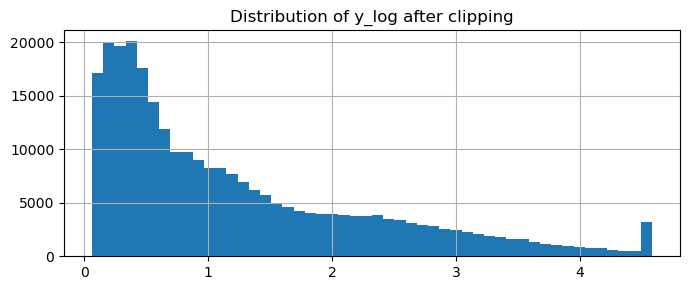

In [179]:
# Clip the log-target at the 1st and 99th percentile to reduce the influence of
# extreme freight rates before any model sees the data.
# Clipping in log-space is gentler than clipping the raw USD values.

_lower_q, _upper_q = 0.01, 0.99
_lower = df_model[TARGET].quantile(_lower_q)
_upper = df_model[TARGET].quantile(_upper_q)

_before_rows = len(df_model)
df_model[TARGET] = df_model[TARGET].clip(lower=_lower, upper=_upper)

# Also clip the lag / rolling features that are derived from the target
# (they will be recomputed in Step 2, so this just guards the source column)
print(f"Clipping '{TARGET}' to [{_lower:.4f}, {_upper:.4f}]  "
      f"(p{int(_lower_q*100)} – p{int(_upper_q*100)})")
print(f"Rows unchanged: {_before_rows}  |  "
      f"New target range: [{df_model[TARGET].min():.4f}, {df_model[TARGET].max():.4f}]")

df_model[[TARGET]].hist(bins=50, figsize=(7, 3))
plt.title(f"Distribution of {TARGET} after clipping")
plt.tight_layout()
plt.show()


## Step 2 — Feature Engineering & Train / Test Split


In [180]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── 1. Lag & rolling-mean features (within each group) ───────────────────────
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

for lag in [1, 2, 3]:
    df_model[f"target_lag_{lag}"] = (
        df_model.groupby(GROUP_COLS)[TARGET].shift(lag)
    )

df_model["target_rolling_mean_3"] = (
    df_model.groupby(GROUP_COLS)[TARGET]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── 2. Encode categorical group columns for XGBoost ──────────────────────────
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()
le_product = LabelEncoder()

df_model["origin_enc"]  = le_origin.fit_transform(df_model["Origin_Label"])
df_model["dest_enc"]    = le_dest.fit_transform(df_model["Destination_Label"])
df_model["product_enc"] = le_product.fit_transform(df_model["Product_Code"].astype(str))

# ── 3. All feature columns for XGBoost ───────────────────────────────────────
XGB_FEATURES = (
    FEATURE_COLS
    + ["target_lag_1", "target_lag_2", "target_lag_3", "target_rolling_mean_3"]
    + ["origin_enc", "dest_enc", "product_enc", TIME_COL]
)

# Ensure XGB_FEATURES is a flat list of column names
_flat_xgb = []
for c in XGB_FEATURES:
    if isinstance(c, (list, tuple)):
        _flat_xgb.extend(list(c))
    else:
        _flat_xgb.append(c)
XGB_FEATURES = _flat_xgb

# Fill remaining NaN values in lag/rolling cols with column medians
df_model[XGB_FEATURES] = df_model[XGB_FEATURES].fillna(
    df_model[XGB_FEATURES].median(numeric_only=True)
)

# ── 4. Temporal split: last 2 years as test ───────────────────────────────────
max_year  = df_model[TIME_COL].max()
split_year = max_year - 1          # train ≤ (max-2), test = last 2 years

df_train = df_model[df_model[TIME_COL] <= split_year].copy()
df_test  = df_model[df_model[TIME_COL] >  split_year].copy()

print(f"Train years: {df_train[TIME_COL].min()} – {df_train[TIME_COL].max()}  |  rows: {len(df_train)}")
print(f"Test  years: {df_test[TIME_COL].min()}  – {df_test[TIME_COL].max()}  |  rows: {len(df_test)}")

# ── 5. StandardScaling on numeric FEATURE_COLS (fit on train only) ────────────
scaler = StandardScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

print("\nFeature means after scaling (train, should be ~0):")
print(df_train[FEATURE_COLS].mean().round(4))


Train years: 2016 – 2020  |  rows: 230728
Test  years: 2021  – 2021  |  rows: 46335

Feature means after scaling (train, should be ~0):
Source_CPI_Annual_average_growth_rate_Value                      -0.0
Destination_CPI_Annual_average_growth_rate_Value                  0.0
Source_GDP_US_at_current_prices_in_millions_Value                -0.0
Destination_GDP_US_at_current_prices_in_millions_Value            0.0
Source_GNI_US_dollars_at_current_prices_in_millions_Value        -0.0
Destination_GNI_US_dollars_at_current_prices_in_millions_Value   -0.0
lsbci                                                            -0.0
dist_km                                                           0.0
fuel_vlsfo_avg                                                   -0.0
lsci_o                                                            0.0
lsci_d                                                            0.0
lsci_sum                                                          0.0
lsci_gap                

## Step 3 — XGBoost Baseline


[0]	validation_0-mae:0.84184
[100]	validation_0-mae:0.41267
[200]	validation_0-mae:0.40494
[272]	validation_0-mae:0.40148

XGBoost Test Results (log scale):
  MAE  : 0.4012
  RMSE : 0.5907
  R²   : 0.7172

XGBoost Test Results (original USD/kg scale, back-transformed):
  MAE  : 4.9591
  RMSE : 13.0183


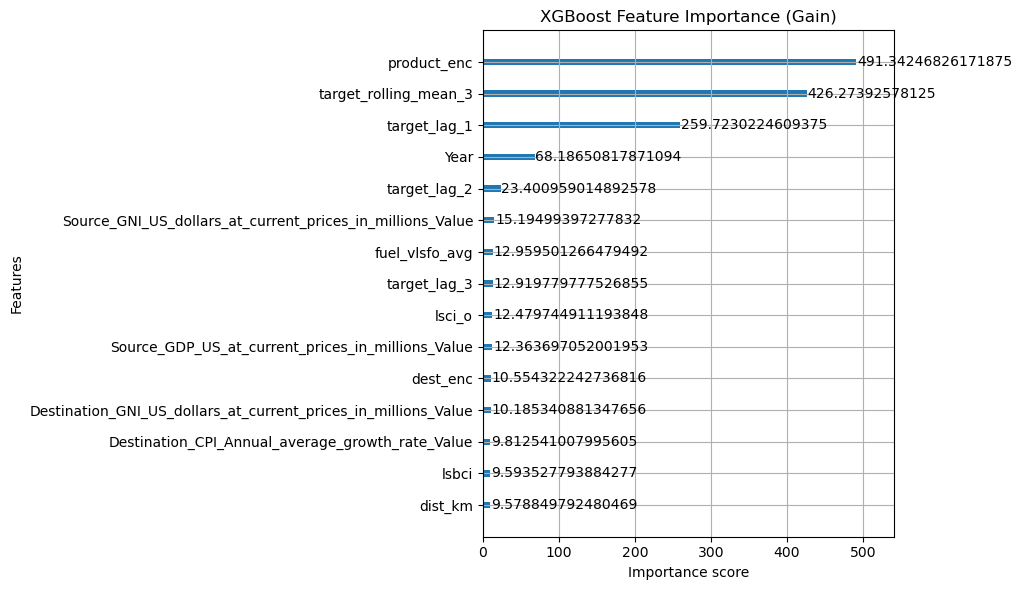

In [181]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_train = df_train[XGB_FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[XGB_FEATURES]
y_test  = df_test[TARGET]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="mae",
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

# Back-transform log predictions to USD for interpretability
mae_xgb_usd  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb))
rmse_xgb_usd = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_xgb)))

print(f"\nXGBoost Test Results (log scale):")
print(f"  MAE  : {mae_xgb:.4f}")
print(f"  RMSE : {rmse_xgb:.4f}")
print(f"  R²   : {r2_xgb:.4f}")
print(f"\nXGBoost Test Results (original USD/kg scale, back-transformed):")
print(f"  MAE  : {mae_xgb_usd:.4f}")
print(f"  RMSE : {rmse_xgb_usd:.4f}")

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=15, ax=ax, importance_type="gain")
ax.set_title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()


## Step 4 — Temporal Fusion Transformer (TFT)

TFT requires:
- A `time_idx` integer column (0-based, continuous per group)
- A `group_id` column identifying each time-series
- Known future covariates (Year, product) and observed covariates (CPI, GDP, GNI, LSBCI, Distance)


In [182]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE as TFT_MAE
import lightning.pytorch as pl
import torch

# ── 1. Build group_id + time_idx ─────────────────────────────────────────────
df_tft = df_model.copy()

# Unique series ID per (origin, destination, product)
df_tft["group_id"] = (
    df_tft["Origin_Label"].astype(str) + "|"
    + df_tft["Destination_Label"].astype(str) + "|"
    + df_tft["Product_Code"].astype(str)
)

# time_idx: 0-based integer index within each group
min_year = df_tft[TIME_COL].min()
df_tft["time_idx"] = df_tft[TIME_COL] - min_year

# ── 2. Filter out series that are too short ───────────────────────────────────
MIN_SERIES_LEN = 6
series_len = df_tft.groupby("group_id")["time_idx"].count()
long_series = series_len[series_len >= MIN_SERIES_LEN].index
df_tft = df_tft[df_tft["group_id"].isin(long_series)].reset_index(drop=True)

print(f"Series remaining after length filter: {df_tft['group_id'].nunique()}")
print(f"Total rows for TFT: {len(df_tft)}")

# ── 3. Prediction & encoder lengths ──────────────────────────────────────────
MAX_PREDICTION_LENGTH = 2   # predict 2 years ahead
MAX_ENCODER_LENGTH    = 4   # look-back window

max_time_idx = df_tft["time_idx"].max()
training_cutoff = max_time_idx - MAX_PREDICTION_LENGTH

# keep only groups that have at least one observation in the training window
train_groups = df_tft.loc[df_tft["time_idx"] <= training_cutoff, "group_id"].unique()
df_tft = df_tft[df_tft["group_id"].isin(train_groups)].reset_index(drop=True)

# ── 4. Categorical columns must be strings ────────────────────────────────────
for col in ["group_id", "Product_Code"]:
    df_tft[col] = df_tft[col].astype(str)

# ── 5. Build TimeSeriesDataSet ─────────────────────────────────────────────────
training_dataset = TimeSeriesDataSet(
    df_tft[df_tft["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target=TARGET,
    group_ids=["group_id"],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=1,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["group_id", "Product_Code"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=FEATURE_COLS + [TARGET],
    target_normalizer=GroupNormalizer(groups=["group_id"], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
 )

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    df_tft,
    predict=True,
    stop_randomization=True,
 )

BATCH_SIZE = 64
train_loader = training_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_loader   = validation_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print("DataLoaders created.")


Series remaining after length filter: 25741
Total rows for TFT: 189532


c:\Users\xianj\anaconda3\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 352 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': 'Afghanistan|Switzerland, Liechtenstein|9404'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|2106'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|6109'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|8517'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|9404'}, {'__group_id__group_id': 'American Samoa|Switzerland, Liechtenstein|3304'}, {'__group_id__group_id': 'Armenia|Switzerland, Liechtenstein|8517'}, {'__group_id__group_id': 'Armenia|Switzerland, Liechtenstein|9404'}, {'__group_id__group_id': 'Bahamas|Switzerland, Liechtenstein|2106'

DataLoaders created.


c:\Users\xianj\anaconda3\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 282 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': 'Afghanistan|Switzerland, Liechtenstein|8517'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|2106'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|6109'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|8517'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein|9404'}, {'__group_id__group_id': 'American Samoa|Switzerland, Liechtenstein|3304'}, {'__group_id__group_id': 'Argentina|Switzerland, Liechtenstein|6109'}, {'__group_id__group_id': 'Argentina|Switzerland, Liechtenstein|8517'}, {'__group_id__group_id': 'Armenia|Switzerland, Liechtenstein|8

In [183]:
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42)

tft_model = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=3e-3,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,           # 7 quantiles: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    loss=QuantileLoss(),
    log_interval=-1,         # disable interpretation logging to avoid histogram error
    reduce_on_plateau_patience=4,
)

print(f"Number of parameters in TFT: {tft_model.size() / 1e3:.1f}k")

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    gradient_clip_val=0.1,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False,
)

trainer.fit(tft_model, train_dataloaders=train_loader, val_dataloaders=val_loader)


Seed set to 42
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in TFT: 918.7k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  820 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    608 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 34.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 918 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 918 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 479                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


In [187]:

# ── Predictions on validation set — returned in y_log scale via mode="prediction"
# mode="prediction" applies GroupNormalizer.inverse_transform so output is back in y_log space.

_tft_out = tft_model.predict(val_loader, mode="prediction", return_x=True)

# Unpack: pytorch-forecasting may return a namedtuple or a (preds, x) tuple
if hasattr(_tft_out, "prediction"):
    tft_preds_tensor = _tft_out.prediction
    _x = getattr(_tft_out, "x", None)
elif isinstance(_tft_out, (list, tuple)) and len(_tft_out) >= 2:
    tft_preds_tensor = _tft_out[0]
    _x = _tft_out[1]
else:
    tft_preds_tensor = _tft_out
    _x = None

tft_preds_np = tft_preds_tensor.cpu().numpy()          # (N, horizon) or (N, horizon, quantiles)
if tft_preds_np.ndim == 3:
    tft_preds_np = tft_preds_np[:, :, 3]               # median quantile (index 3 = 0.5)
elif tft_preds_np.ndim == 1:
    tft_preds_np = tft_preds_np.reshape(-1, 1)

# Helper: get a key from _x whether it's a dict or an object
def _xget(obj, key, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)

# ── Align predictions with df_tft actuals ────────────────────────────────────
_g_enc       = training_dataset.categorical_encoders.get("group_id")
_groups_t    = _xget(_x, "groups")
_dec_time_t  = _xget(_x, "decoder_time_idx")
_enc_start_t = _xget(_x, "encoder_time_idx_start")
_enc_len_t   = _xget(_x, "encoder_lengths")

tft_aligned_full = None

if _groups_t is not None:
    _g_ints  = _groups_t.cpu().numpy().flatten().astype(int)
    _g_names = (
        np.array(_g_enc.classes_)[_g_ints]
        if (_g_enc is not None and hasattr(_g_enc, "classes_"))
        else _g_ints.astype(str)
    )

    if _dec_time_t is not None:
        # Most direct: decoder_time_idx has the actual time_idx per step
        _dtix = _dec_time_t.cpu().numpy()
        if _dtix.ndim == 1:
            _dtix = _dtix.reshape(len(_g_names), -1)
        _aln_rows = [
            {"group_id": _g_names[i], "time_idx": int(_dtix[i, h]), "y_pred": float(tft_preds_np[i, h])}
            for i in range(len(_g_names)) for h in range(tft_preds_np.shape[1])
        ]
        tft_aligned_full = pd.DataFrame(_aln_rows)

    elif _enc_start_t is not None and _enc_len_t is not None:
        _dec_starts = (_enc_start_t + _enc_len_t).cpu().numpy().flatten().astype(int)
        _aln_rows = [
            {"group_id": _g_names[i], "time_idx": _dec_starts[i] + h, "y_pred": float(tft_preds_np[i, h])}
            for i in range(len(_g_names)) for h in range(tft_preds_np.shape[1])
        ]
        tft_aligned_full = pd.DataFrame(_aln_rows)

if tft_aligned_full is None:
    # Fallback: use the dataset's internal index (attribute name varies by version)
    _di = None
    for _attr in ("index", "data_index"):
        if hasattr(validation_dataset, _attr):
            _di = getattr(validation_dataset, _attr).copy()
            break

    if _di is not None:
        _g_col   = next((c for c in ["group_id", "groups"] if c in _di.columns), _di.columns[0])
        _g_vals  = _di[_g_col].values.flatten()
        if _g_enc is not None and hasattr(_g_enc, "classes_") and np.issubdtype(_g_vals.dtype, np.integer):
            _g_names = np.array(_g_enc.classes_)[_g_vals.astype(int)]
        else:
            _g_names = _g_vals.astype(str)
        _t_col   = next((c for c in ["time_idx_last", "sequence_end", "time_last"] if c in _di.columns), None)
        _cutoffs = _di[_t_col].values.astype(int) if _t_col else np.full(len(_g_names), training_cutoff + MAX_PREDICTION_LENGTH)
        _aln_rows = [
            {"group_id": _g_names[i],
             "time_idx": _cutoffs[i] - MAX_PREDICTION_LENGTH + h + 1,
             "y_pred":   float(tft_preds_np[i % tft_preds_np.shape[0], h])}
            for i in range(len(_g_names)) for h in range(tft_preds_np.shape[1])
        ]
        tft_aligned_full = pd.DataFrame(_aln_rows)
    else:
        raise RuntimeError(
            "Cannot align TFT predictions: no group info in _x and no index attribute on dataset."
        )

# Join to df_tft for actual y_log values and Product_Code
_lu = df_tft[["group_id", "time_idx", "Product_Code", TARGET]].drop_duplicates(subset=["group_id", "time_idx"])
tft_aligned_full = tft_aligned_full.merge(_lu, on=["group_id", "time_idx"], how="inner")

print(f"TFT aligned: {len(tft_aligned_full)} prediction-actual pairs "
      f"(expected ≈{df_tft['group_id'].nunique() * MAX_PREDICTION_LENGTH})")

y_pred_tft_median = tft_aligned_full["y_pred"].values
y_actuals         = tft_aligned_full[TARGET].values

mae_tft  = mean_absolute_error(y_actuals, y_pred_tft_median)
rmse_tft = np.sqrt(mean_squared_error(y_actuals, y_pred_tft_median))
r2_tft   = r2_score(y_actuals, y_pred_tft_median)

# Back-transform to USD/kg — correct because both are in y_log space
mae_tft_usd  = mean_absolute_error(np.expm1(y_actuals), np.expm1(y_pred_tft_median))
rmse_tft_usd = np.sqrt(mean_squared_error(np.expm1(y_actuals), np.expm1(y_pred_tft_median)))

print("TFT Validation Results (y_log scale — directly comparable to XGBoost):")
print(f"  MAE  : {mae_tft:.4f}")
print(f"  RMSE : {rmse_tft:.4f}")
print(f"  R²   : {r2_tft:.4f}")
print("\nTFT Validation Results (original USD/kg scale, back-transformed):")
print(f"  MAE  : {mae_tft_usd:.4f}")
print(f"  RMSE : {rmse_tft_usd:.4f}")

# ── Comparison scatter plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_test, y_pred_xgb, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"XGBoost  —  MAE={mae_xgb:.3f}  R²={r2_xgb:.3f}")
axes[0].set_xlabel("Actual (log scale)"); axes[0].set_ylabel("Predicted (log scale)")

axes[1].scatter(y_actuals, y_pred_tft_median, alpha=0.3, s=10, color="orange")
axes[1].plot([y_actuals.min(), y_actuals.max()], [y_actuals.min(), y_actuals.max()], "r--")
axes[1].set_title(f"TFT (median)  —  MAE={mae_tft:.3f}  R²={r2_tft:.3f}")
axes[1].set_xlabel("Actual (log scale)"); axes[1].set_ylabel("Predicted (log scale)")

plt.suptitle("Predicted vs Actual — log1p(Freight_USD_per_kg)", fontsize=13)
plt.tight_layout()
plt.show()

# ── TFT Variable importance (optional) ────────────────────────────────────────
try:
    output_full = tft_model.predict(val_loader, mode="raw", return_index=False)
    if hasattr(output_full, "prediction"):
        interpretation = tft_model.interpret_output(output_full, reduction="sum")
        tft_model.plot_interpretation(interpretation)
        plt.show()
except RuntimeError as e:
    print("Skipping TFT interpretation due to runtime error:", e)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to i

AttributeError: 'NoneType' object has no attribute 'get'

In [188]:
# ── Mean USD/kg summary ────────────────────────────────────────────────────────
# Back-transform the log target to original USD/kg scale for both splits

mean_train_usd = np.expm1(df_train[TARGET]).mean()
mean_test_usd  = np.expm1(df_test[TARGET]).mean()
mean_xgb_pred  = np.expm1(y_pred_xgb).mean()
mean_tft_pred  = np.expm1(y_pred_tft_median).mean()
mean_actuals_tft = np.expm1(y_actuals).mean()

print("─" * 45)
print(f"{'Mean Freight Rate (USD/kg)':}")
print("─" * 45)
print(f"  Train set actuals      : {mean_train_usd:.4f}")
print(f"  Test  set actuals      : {mean_test_usd:.4f}")
print(f"  XGBoost predictions    : {mean_xgb_pred:.4f}")
print(f"  TFT predictions        : {mean_tft_pred:.4f}")
print(f"  TFT validation actuals : {mean_actuals_tft:.4f}")
print("─" * 45)

# Also show per-product mean in the test set
print("\nMean USD/kg by product (test set actuals):")
per_product = (
    df_test.assign(Freight_USD_per_kg=np.expm1(df_test[TARGET]))
    .groupby("Product_Code")["Freight_USD_per_kg"]
    .mean()
    .sort_values(ascending=False)
)
print(per_product.round(4).to_string())


─────────────────────────────────────────────
Mean Freight Rate (USD/kg)
─────────────────────────────────────────────
  Train set actuals      : 6.0575
  Test  set actuals      : 8.7446
  XGBoost predictions    : 4.2526
  TFT predictions        : 3.0788
  TFT validation actuals : 5.9291
─────────────────────────────────────────────

Mean USD/kg by product (test set actuals):
Product_Code
8517    27.5113
6109     5.1635
3304     2.8085
9404     1.6658
2106     1.5555


In [189]:

# ── Per-product evaluation: XGBoost ───────────────────────────────────────────
xgb_eval = df_test[["Product_Code", TARGET]].copy()
xgb_eval["y_pred"] = y_pred_xgb

rows_xgb = []
for prod, grp in xgb_eval.groupby("Product_Code"):
    if len(grp) < 2:
        continue
    mae_log  = mean_absolute_error(grp[TARGET], grp["y_pred"])
    rmse_log = np.sqrt(mean_squared_error(grp[TARGET], grp["y_pred"]))
    r2_log   = r2_score(grp[TARGET], grp["y_pred"])
    mae_usd  = mean_absolute_error(np.expm1(grp[TARGET]), np.expm1(grp["y_pred"]))
    rmse_usd = np.sqrt(mean_squared_error(np.expm1(grp[TARGET]), np.expm1(grp["y_pred"])))
    rows_xgb.append({
        "Product_Code": prod,
        "Mean Actual (USD/kg)": np.expm1(grp[TARGET]).mean(),
        "MAE (log)": mae_log, "RMSE (log)": rmse_log, "R2 (log)": r2_log,
        "MAE (USD/kg)": mae_usd, "RMSE (USD/kg)": rmse_usd,
        "n": len(grp)
    })

df_xgb_prod = pd.DataFrame(rows_xgb).sort_values("MAE (log)")
print("XGBoost — per-product metrics:")
print(df_xgb_prod.round(4).to_string(index=False))

# ── Per-product evaluation: TFT ───────────────────────────────────────────────
# tft_aligned_full is created in the TFT eval cell.
# It has: group_id, time_idx, y_pred (y_log scale), Product_Code, y_log (actual)

if "tft_aligned_full" not in dir() or tft_aligned_full is None or len(tft_aligned_full) == 0:
    print("\nTFT per-product evaluation skipped — run the TFT eval cell first.")
    df_tft_prod = pd.DataFrame()
else:
    rows_tft = []
    for prod, grp in tft_aligned_full.groupby("Product_Code"):
        if len(grp) < 2:
            continue
        mae_log  = mean_absolute_error(grp[TARGET], grp["y_pred"])
        rmse_log = np.sqrt(mean_squared_error(grp[TARGET], grp["y_pred"]))
        r2_log   = r2_score(grp[TARGET], grp["y_pred"])
        mae_usd  = mean_absolute_error(np.expm1(grp[TARGET]), np.expm1(grp["y_pred"]))
        rmse_usd = np.sqrt(mean_squared_error(np.expm1(grp[TARGET]), np.expm1(grp["y_pred"])))
        rows_tft.append({
            "Product_Code": prod,
            "Mean Actual (USD/kg)": np.expm1(grp[TARGET]).mean(),
            "MAE (log)": mae_log, "RMSE (log)": rmse_log, "R2 (log)": r2_log,
            "MAE (USD/kg)": mae_usd, "RMSE (USD/kg)": rmse_usd,
            "n": len(grp)
        })

    df_tft_prod = pd.DataFrame(rows_tft).sort_values("MAE (log)")
    print("\nTFT — per-product metrics:")
    print(df_tft_prod.round(4).to_string(index=False))

    # ── Side-by-side bar charts ────────────────────────────────────────────────
    products = sorted(set(df_xgb_prod["Product_Code"]) & set(df_tft_prod["Product_Code"]))
    x = np.arange(len(products))
    w = 0.35
    xgb_idx = df_xgb_prod.set_index("Product_Code")
    tft_idx = df_tft_prod.set_index("Product_Code")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(x - w/2, [xgb_idx.loc[p, "MAE (log)"]  for p in products], w, label="XGBoost", color="steelblue")
    axes[0].bar(x + w/2, [tft_idx.loc[p, "MAE (log)"]  for p in products], w, label="TFT",     color="orange")
    axes[0].set_xticks(x); axes[0].set_xticklabels(products)
    axes[0].set_ylabel("MAE (log scale)"); axes[0].set_title("Per-Product MAE — Log Scale")
    axes[0].legend()

    axes[1].bar(x - w/2, [xgb_idx.loc[p, "MAE (USD/kg)"] for p in products], w, label="XGBoost", color="steelblue")
    axes[1].bar(x + w/2, [tft_idx.loc[p, "MAE (USD/kg)"] for p in products], w, label="TFT",     color="orange")
    axes[1].set_xticks(x); axes[1].set_xticklabels(products)
    axes[1].set_ylabel("MAE (USD/kg)"); axes[1].set_title("Per-Product MAE — USD/kg Scale")
    axes[1].legend()

    plt.suptitle("Per-Product MAE: XGBoost vs TFT", fontsize=13)
    plt.tight_layout()
    plt.show()


XGBoost — per-product metrics:
 Product_Code  Mean Actual (USD/kg)  MAE (log)  RMSE (log)  R2 (log)  MAE (USD/kg)  RMSE (USD/kg)     n
         2106                1.5555     0.2521      0.4190    0.3722        0.9094         4.3083  9422
         9404                1.6658     0.2762      0.4145    0.2673        0.8561         2.3912  7221
         6109                5.1635     0.3295      0.4900    0.3823        2.1704         5.3323  9789
         3304                2.8085     0.3650      0.5311    0.3543        1.6663         6.0257  8890
         8517               27.5113     0.7039      0.8740    0.0500       16.2506        25.2750 11013

TFT per-product evaluation skipped — run the TFT eval cell first.
